In [2]:
from skimage import data, color
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve, correlate
import time
import pywt

In [3]:
print(dir(data))

['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


(512, 512)


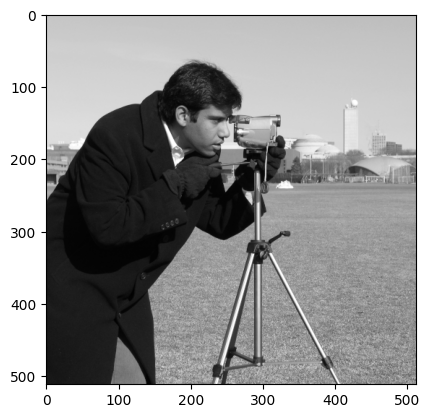

In [4]:
image = data.camera() # Carregar imagem
#image = color.rgb2gray(image) # Mudar p/ preto e branco
n = image.shape[0] # Tamanho da imagem

# n = max(image.shape)
# image = resize(image, (n, n), anti_aliasing=True) # Imagem quadrada

print(image .shape)
plt.imshow(image , cmap='grey')

In [5]:
n_kernel = 7 # Dimensão do kernel

# Imagem constante
kernel = np.full((n_kernel, n_kernel), 1/(n_kernel**2))

# Definir operadores
def A(x):
    return convolve(x, kernel, mode='same')

def AT(x):
    return correlate(x, kernel, mode='same')

In [6]:
# Verificar se A é adjunta de de AT

x = 10*np.random.rand(image.shape[0], image.shape[1])
y = 10*np.random.rand(image.shape[0], image.shape[1])

print(np.sum(A(x)*y))
print(np.sum(x*AT(y)))

6512055.179177932
6512055.1791779315


In [7]:
# Wavelet escolhida
wav = 'db5'

def H(x):
    coeffs = pywt.wavedec2(x, wav, mode='periodization')
    arr, slices = pywt.coeffs_to_array(coeffs)
    return arr, slices

def HT(arr, slices):
    coeffs = pywt.array_to_coeffs(arr, slices, output_format='wavedec2')
    return pywt.waverec2(coeffs, wav, mode='periodization')


In [8]:
# Verificar se H é adjunta de HT

x = 10*np.random.rand(image.shape[0], image.shape[1])
y = 10*np.random.rand(image.shape[0], image.shape[1])

Hx = H(x)
print(np.sum(Hx[0]*y))
print(np.sum(x*HT(y, Hx[1])))

err = np.abs(image - HT(*H(image)))
print(np.sum(err))

218491.13779947866
218491.13779947866
1.810148117509236e-08


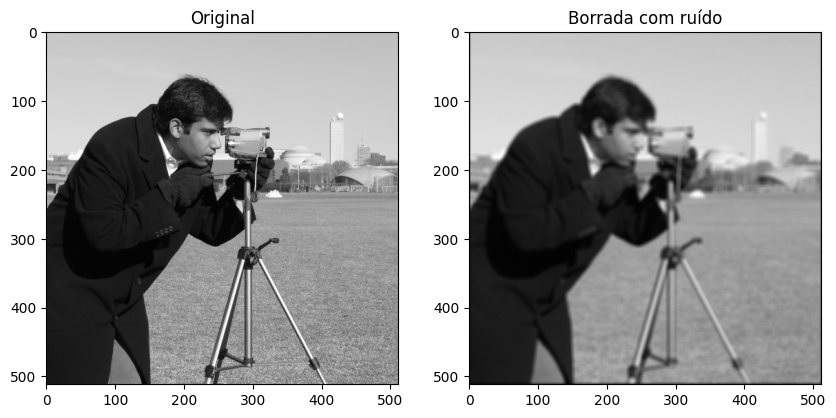

In [9]:
# Imagem borrada e ruida
episilon = 1
b_star = A(image) # Imagem borrada
b = b_star + episilon*np.random.randn(n, n) # Ruido gaussiano

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')

plt.subplot(1, 2, 2)
plt.imshow(b, cmap='gray')
plt.title('Borrada com ruído')

plt.show()

In [10]:
def f(x):
    return 0.5 * np.linalg.norm(A(x) - b)**2

def grad(x):
    return AT(A(x) - b)

def exact_step(x):
    g = grad(x)
    Ag = A(g)               # A * grad
    ATAg = AT(Ag)           # A^T * (A * grad)
    num = np.sum(g * g)     # numerador
    den = np.sum(g * ATAg)  # denominador
    return num / den

# Proximal
def prox(x, alpha):
    Hx = H(x)
    return HT(pywt.threshold(Hx[0], alpha), Hx[1])

# Método ISTA
def ista(x0=None, step=None, prox=None, gamma=None, max_iters=100, tol=None, x_star=None):
    x = np.zeros((n, n)) if x0 is None else x0 # chute inicial
    x_values = [x]
    time_per_iter = [0]

    for k in range(max_iters):

        t0 = time.time()
        if step is None:
            step = exact_step(x) # passo exato

        if prox is not None:
            x = prox(x -step * grad(x), step*gamma)

        x = x -step * grad(x)

        # Critério de parada
        if tol is not None and x_star is not None:
            if np.linalg.norm(x - x_star) / np.linalg.norm(x_star) <= tol:
                print(f"Gradiente parou na iteração {k}")
                x_values.append(x)
                break

        t1 = time.time()
        x_values.append(x)
        time_per_iter.append(t1 - t0)

    return x_values, time_per_iter

# Método de Nesterov
def fista(x0=None, step=None, prox=None, gamma=None, max_iters=100, tol=None, x_star=None):
    x = np.zeros((n, n)) if x0 is None else x0 # chute inicial
    x_values = [x]
    y_prev = np.copy(x)
    t_next = 1
    time_per_iter = [0]

    for k in range(max_iters):

        t0 = time.time()
        if step is None:
            step = exact_step(x) # passo exato

        if prox is not None:
            x = prox(x -step * grad(x), step*gamma)

        y = x - step * grad(x)
        t = t_next
        t_next = 0.5 * (1 + np.sqrt(1 + 4 * t**2))
        x = y + ((t - 1) / t_next) * (y - y_prev)

        # Critério de parada
        if tol is not None and x_star is not None:
            if np.linalg.norm(x - x_star) / np.linalg.norm(x_star) <= tol:
                print(f"Nestererov parou na iteração {k}")
                x_values.append(x)
                break

        y_prev = y
        t1 = time.time()

        time_per_iter.append(t1 - t0)
        x_values.append(x)

    return x_values, time_per_iter

# Método dos Gradientes Conjugados
def conjugate_grad(x0=None, max_iters=100, tol=None, x_star=None):
    x = np.zeros((n, n)) if x0 is None else x0 # chute inicial
    r = AT(b - A(x))
    p = np.copy(r)
    rsold = np.sum(r * r)
    x_values = [x]
    time_per_iter = [0]

    for k in range(max_iters):

        t0 = time.time()
        Ap = AT(A(p))
        alpha = rsold / np.sum(p * Ap)
        x = x + alpha * p

        # Critério de parada
        if tol is not None and x_star is not None:
            if np.linalg.norm(x - x_star) / np.linalg.norm(x_star) <= tol:
                print(f"Nestererov parou na iteração {k}")
                x_values.append(x)
                break

        r = r - alpha * Ap
        rsnew = np.sum(r * r)
        if np.sqrt(rsnew) < 1e-8:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew

        t1 = time.time()
        x_values.append(x)
        time_per_iter.append(t1 - t0)

    return x_values, time_per_iter

In [38]:
#----------------------
# Executar métodos
#----------------------

gamma = 1e-2
iters = 100
methods = {"Gradiente": ista,
           "Nesterov": fista,
           "ISTA": ista,
           "FISTA": fista
           #"CG": conjugate_grad
           }

steps = {"fixo: 1.3": 1.3,
         "exato": None
         }

results = {}
for method_name, method in methods.items():

    for step_name, step_value in steps.items():

        print(f"Executando {method_name} com passo {step_name}")

        if method_name == "Gradiente" or method_name == "Nesterov":
            x_values, time_iter = method(step=step_value, max_iters=iters)
        elif method_name == "ISTA" or method_name == "FISTA":
            x_values, time_iter = method(step=step_value,
                                         prox=prox,
                                         gamma=gamma,
                                         max_iters=iters)
        else:
            x_values, time_iter = method(max_iters=iters)

        f_values = [f(x) + gamma*np.sum(np.abs(H(x)[0])) for x in x_values]
        reconstruction = x_values[np.argmin(f_values)]

        results[(method_name, step_name)] = {"x_values": x_values,
                                             "time": time_iter,
                                             "reconstruction": reconstruction,
                                             "f_values": f_values}
# Gradientes conjugados
x_values_cg, time_iter_cg = conjugate_grad()
f_values_cg = [f(x) + gamma*np.sum(np.abs(H(x)[0])) for x in x_values_cg]
reconstruction_cg = x_values_cg[np.argmin(f_values_cg)]

Executando Gradiente com passo fixo: 1.3
Executando Gradiente com passo exato
Executando Nesterov com passo fixo: 1.3
Executando Nesterov com passo exato
Executando ISTA com passo fixo: 1.3
Executando ISTA com passo exato
Executando FISTA com passo fixo: 1.3
Executando FISTA com passo exato


In [40]:
valores_min = []
m = 10000000
for key, data in results.items():
    method, step = key
    print(f"Método: {method}, passo: {step}")
    valores_min.append(min(data['f_values']))
    if min(data['f_values']) < m:
        m = min(data['f_values'])
        method_min = method
        step_min = step
    print(f"Valor minimimo: {min(data['f_values'])}", end="\n\n")

print(f"Min grad conj: {min(f_values_cg)}", end="\n\n")
print(f"Método: {method_min}, passo: {step_min}")
print(f"Valor mínimimo de todos os métodos: {m}")

Método: Gradiente, passo: fixo: 1.3
Valor minimimo: 129386.89022988707

Método: Gradiente, passo: exato
Valor minimimo: 135740.0133498747

Método: Nesterov, passo: fixo: 1.3
Valor minimimo: 106253.61320143628

Método: Nesterov, passo: exato
Valor minimimo: 106275.36408509

Método: ISTA, passo: fixo: 1.3
Valor minimimo: 117889.96166952283

Método: ISTA, passo: exato
Valor minimimo: 121684.74563169669

Método: FISTA, passo: fixo: 1.3
Valor minimimo: 101808.94161925706

Método: FISTA, passo: exato
Valor minimimo: 101851.95965726179

Min grad conj: 112369.29762684938

Método: FISTA, passo: fixo: 1.3
Valor mínimimo de todos os métodos: 101808.94161925706


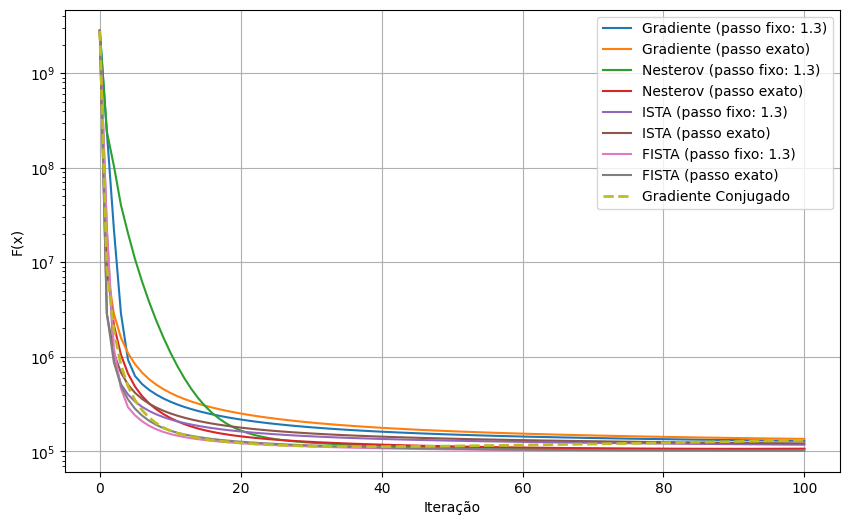

In [41]:
plt.figure(figsize=(10, 6))

# curvas dos métodos
for key, data in results.items():
    method, step = key
    plt.plot(data["f_values"], label=f"{method} (passo {step})")

# curva do gradiente conjugado (referência)
plt.plot(f_values_cg, linestyle="--", linewidth=2, label="Gradiente Conjugado")

plt.yscale("log")
plt.xlabel("Iteração")
plt.ylabel("F(x)")
plt.legend()
plt.grid(True)

plt.show()

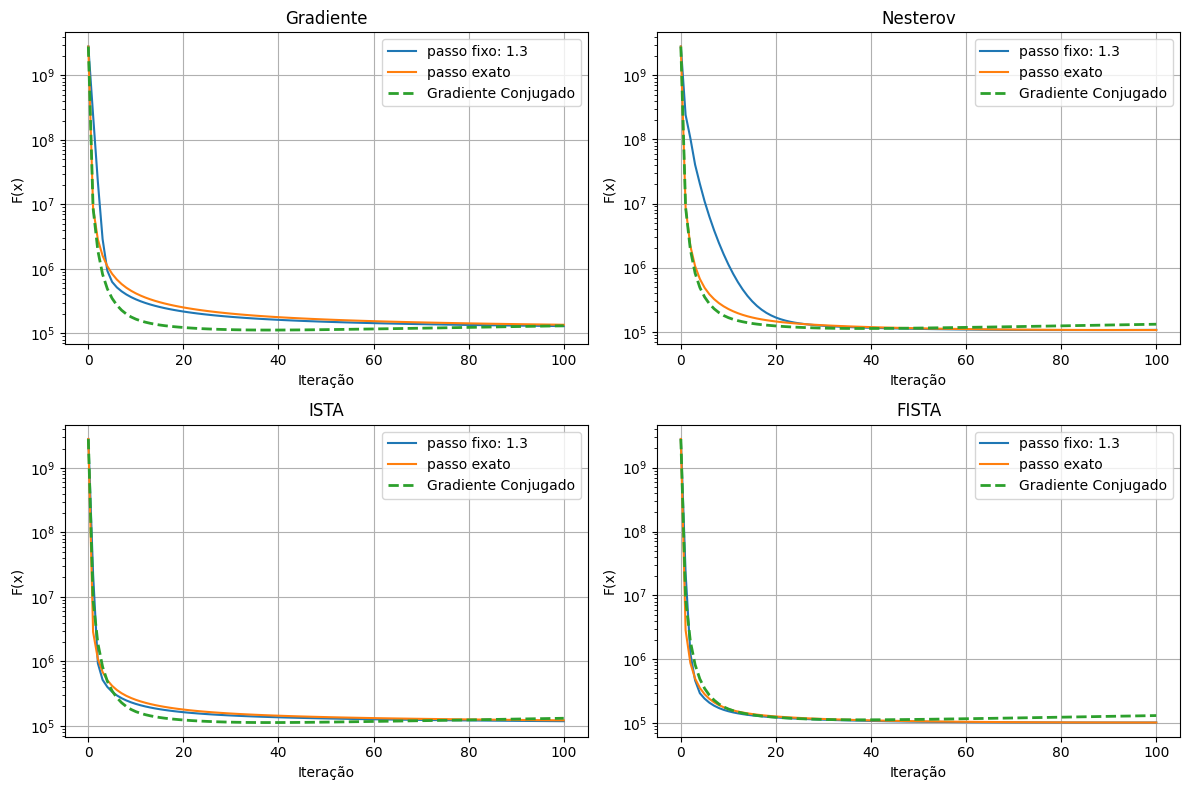

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

method_list = list(methods.keys())
step_list = list(steps.keys())

for idx, method_name in enumerate(method_list):

    ax = axes[idx // 2, idx % 2]   # posiciona no grid 2x2

    for step_name in step_list:

        key = (method_name, step_name)

        if key in results:
            data = results[key]
            ax.plot(data["f_values"], label=f"passo {step_name}")

    # curva do gradiente conjugado (referência)
    ax.plot(f_values_cg, linestyle="--", linewidth=2, label="Gradiente Conjugado")

    ax.set_title(method_name)
    ax.set_yscale("log")
    ax.set_xlabel("Iteração")
    ax.set_ylabel("F(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# FISTA
x_values_fista_ref, time_iter_fista_ref = fista(prox=prox, gamma=gamma, max_iters=500)
reconstruction_fista_ref = x_values_fista_ref[-1]
f_values_fista_ref = [f(x) + gamma*np.sum(np.abs(H(x)[0])) for x in x_values_fista_ref]

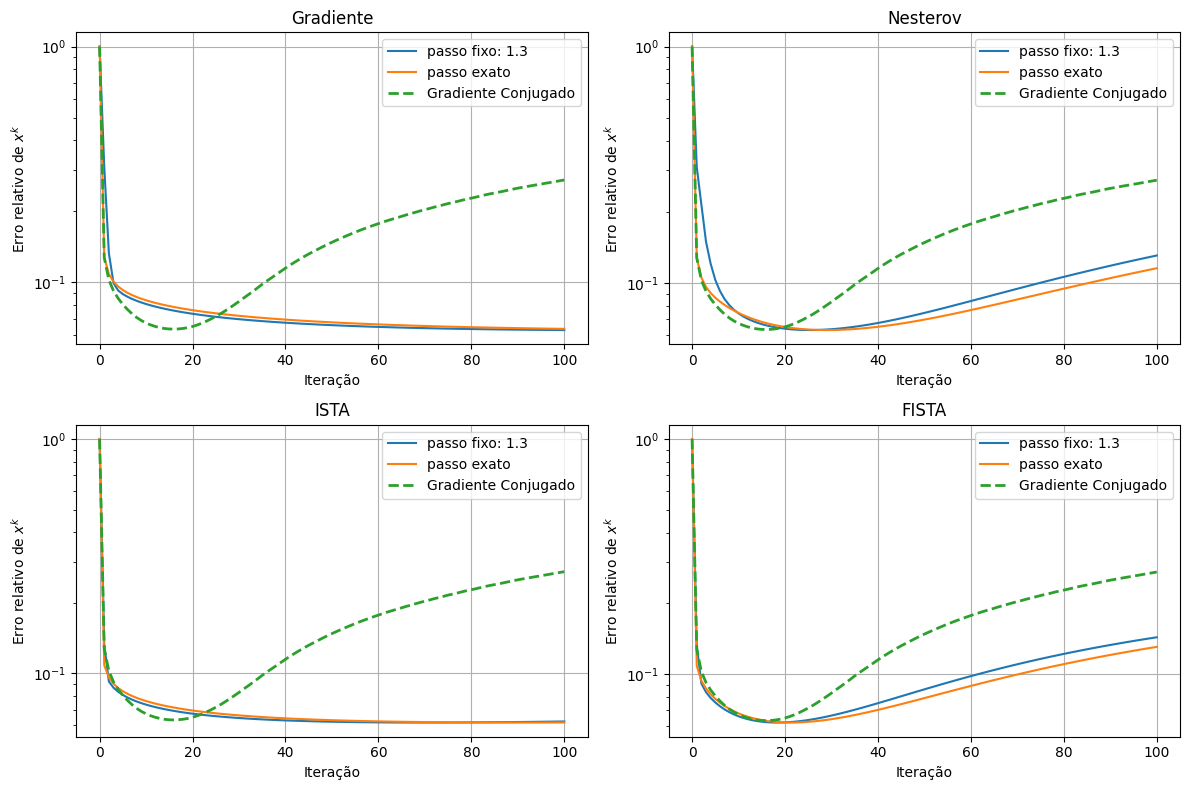

In [44]:
#--------------------------
# Analise erros relativos
#--------------------------

erro_x = {}
erro_f = {}

for key, data in results.items():

    method, step = key

    x_values = data["x_values"]
    f_values = data["f_values"]

    # erro relativo de x
    erro_x[key] = [
        np.linalg.norm(x - image) / np.linalg.norm(image)
        for x in x_values
    ]

erro_img_cg = [np.linalg.norm(x - image) / np.linalg.norm(image) for x in x_values_cg]

# ----------------------------
# Plot dos graficos de erro
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

method_list = list(methods.keys())
step_list = list(steps.keys())

for idx, method_name in enumerate(method_list):

    ax = axes[idx // 2, idx % 2]

    for step_name in step_list:

        key = (method_name, step_name)

        if key in erro_x:
            err = erro_x[key]
            ax.plot(err, label=f"passo {step_name}")

    # curva do gradiente conjugado (referência)
    ax.plot(erro_img_cg , linestyle="--", linewidth=2, label="Gradiente Conjugado")

    ax.set_title(method_name)
    ax.set_xlabel("Iteração")
    ax.set_ylabel(r"Erro relativo de $x^k$")
    ax.set_yscale("log")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Análise do ganho de velocidade de convergência

In [ ]:
# # ----------------------------
# # Visualização
# # ----------------------------
# plt.figure(figsize=(15, 7))

# # Imagem original
# plt.subplot(1, 4, 1)
# plt.title("Imagem original")
# plt.imshow(image, cmap="gray")
# plt.axis("off")

# # Reconstrução - Gradientes Conjugados
# plt.subplot(1, 4, 2)
# plt.title("Grad. Conjugados")
# plt.imshow(reconstruction_cg, cmap="gray")
# plt.axis("off")

# # Reconstrução - Gradiente passo exato
# plt.subplot(1, 4, 3)
# plt.title("Nesterov (Passo exato)")
# plt.imshow(reconstruction_n, cmap="gray")
# plt.axis("off")

# # Reconstrução - Gradiente passo fixo
# plt.subplot(1, 4, 4)
# plt.title("FISTA")
# plt.imshow(reconstruction_f, cmap="gray")
# plt.axis("off")

# plt.tight_layout()
# plt.show()